<a href="https://colab.research.google.com/github/RayCharles8/ML-Project/blob/main/GNN_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive and import all libraries
import os
import sys
import numpy as np
import pandas as pd
import random
from tqdm import tqdm

!pip install torch-geometric torch-cluster pymatgen

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Dataset, DataLoader, Batch
from torch_geometric.nn import CGConv, global_mean_pool, GATConv, Set2Set, MessagePassing
from torch_geometric.explain import GNNExplainer
from torch_cluster import radius_graph
from torch_geometric.utils import scatter
from pymatgen.io.cif import CifParser
from pymatgen.core import Structure, Element
from torch.utils.data import Subset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

import matplotlib.pyplot as plt
import seaborn as sns

!pip install pysr
from pysr import PySRRegressor

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
BASE_DIR = "/content/drive/MyDrive/IML Project"

DATA_PATH = os.path.join(BASE_DIR, "Dataset.csv")
CIF_DIR = os.path.join(BASE_DIR)

GRAPH_DIR = os.path.join(BASE_DIR, "graphs")
os.makedirs(GRAPH_DIR, exist_ok=True)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 6.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1

/usr/local/lib/python3.12/dist-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.12/dist-packages/pysr/juliapkg.json
[juliapkg] Locating Julia 1.10.3 - 1.11
[juliapkg] WARNING: You have Julia 1.12.6 installed but 1.10.3 - 1.11 is required.
[juliapkg]   It is recommended that you upgrade Julia or install JuliaUp.
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.9 to /root/.julia/environments/pyjuliapkg/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloads) yourself.
[juliapkg] Downloading Julia

# Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,mp_material_id,mp_formula,spacegroup,spacegroup_number,number of atoms,Band Gap,a,b,c,alpha,beta,gamma,Z,electronegativity,Topological Label,label,cif
0,mp-573069,Ba2CaTl2(CuO4)2,I4/mmm,139,30,0.0000,3.950204,3.950204,30.646282,90.0,90.000000,90.0,27.733333,2.489333,Trivial,0,cifs/mp-573069.cif
1,mp-1193609,PH8IN4,P4/nbm,125,28,1.1111,7.704433,7.704433,7.932095,90.0,90.000000,90.0,7.428571,2.472143,TI,1,cifs/mp-1193609.cif
2,mp-21420,Nd(MnGe)2,I4/mmm,139,10,0.0000,4.173254,4.173254,11.115354,90.0,90.000000,90.0,34.800000,1.652000,TI,1,cifs/mp-21420.cif
3,mp-4920,Nd(GeRh)2,I4/mmm,139,10,0.0000,4.157947,4.157947,10.458460,90.0,90.000000,90.0,42.800000,1.944000,TI,1,cifs/mp-4920.cif
4,mp-15827,Ho2Ge2Os,C2/m,12,20,0.0000,10.699596,4.275589,10.037210,90.0,118.097977,90.0,54.800000,1.736000,TI,1,cifs/mp-15827.cif


In [3]:
print("Total samples:", len(df))

Total samples: 9668


In [4]:
#Check class balance
print("\nLabel distribution:")
print(df['label'].value_counts())


Label distribution:
label
0    5198
1    4470
Name: count, dtype: int64


In [5]:
# Build absolute CIF paths
df['cif_path'] = df['cif'].apply(lambda x: os.path.join(CIF_DIR, x))

# Quick check
print(df[['cif', 'cif_path']].head())

                   cif                                           cif_path
0   cifs/mp-573069.cif  /content/drive/MyDrive/IML Project/cifs/mp-573...
1  cifs/mp-1193609.cif  /content/drive/MyDrive/IML Project/cifs/mp-119...
2    cifs/mp-21420.cif  /content/drive/MyDrive/IML Project/cifs/mp-214...
3     cifs/mp-4920.cif  /content/drive/MyDrive/IML Project/cifs/mp-492...
4    cifs/mp-15827.cif  /content/drive/MyDrive/IML Project/cifs/mp-158...


In [6]:
os.path.exists(df['cif_path'].iloc[0])

True

# Data Splitting

In [7]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 6767 | Val: 1450 | Test: 1451


# Feature Extraction

In [8]:
# Node features
def get_atom_features(element):
    el = Element(element)

    return [
        el.Z,
        el.X if el.X else 0,
        el.atomic_radius if el.atomic_radius else 0,
        el.group if el.group else 0,
        el.row if el.row else 0
    ]

# Global Features
def extract_global_features(row, structure):
    return [
        row['spacegroup_number'],
        row['number of atoms'],
        row['a'], row['b'], row['c'],
        row['alpha'], row['beta'], row['gamma'],
        row['Z'],
        row['electronegativity'],
        row['Band Gap'],
        structure.volume,
        structure.density,
        len(structure.composition.elements)
    ]

# Train Features for Scaling

In [9]:
# COLLECT TRAIN FEATURES
node_samples = []
edge_samples = []
global_samples = []

cutoff = 6.0

for _, row in train_df.iterrows():
    try:
        structure = Structure.from_file(row['cif_path'])

        # Node features
        for site in structure:
            node_samples.append(get_atom_features(site.specie.symbol))

        # Edge features (distance)
        for i, site in enumerate(structure):
            neighbors = structure.get_neighbors(site, cutoff)
            for n in neighbors:
                edge_samples.append([n.nn_distance])

        # Global features
        global_samples.append(extract_global_features(row, structure))

    except Exception as e:
        print(f"Error processing {row['cif_path']} | {e}")

# Convert safely
node_samples = np.array(node_samples)
edge_samples = np.array(edge_samples)
global_samples = np.array(global_samples)

print("Node shape:", node_samples.shape)
print("Edge shape:", edge_samples.shape)
print("Global shape:", global_samples.shape)

Node shape: (211448, 5)
Edge shape: (11843614, 1)
Global shape: (6767, 14)


In [10]:
# SCALING
node_scaler = StandardScaler().fit(node_samples)
edge_scaler = StandardScaler().fit(edge_samples)
global_scaler = StandardScaler().fit(global_samples)

# Gaussian Expansion

In [11]:
# GAUSSIAN EXPANSION

class GaussianDistance:
    def __init__(self, dmin=0, dmax=6, step=0.2):
        self.filter = np.arange(dmin, dmax + step, step)
        self.var = step

    def expand(self, distances):
        return np.exp(-(distances[..., np.newaxis] - self.filter)**2 / self.var**2)

gaussian_expansion = GaussianDistance()

# Building Graphs

In [12]:
def build_graph(row):
    structure = Structure.from_file(row['cif_path'])

    # NODE FEATURES
    node_feat = [get_atom_features(site.specie.symbol) for site in structure]
    node_feat = node_scaler.transform(node_feat)
    x = torch.tensor(node_feat, dtype=torch.float)

    # POSITIONS
    pos = torch.tensor(structure.cart_coords, dtype=torch.float)

    # EDGES
    edge_index = []
    edge_attr = []
    cutoff = 6.0

    for i, site in enumerate(structure):
        neighbors = structure.get_neighbors(site, cutoff)
        for n in neighbors:
            j = n.index
            dist = n.nn_distance

            edge_index.append([i, j])
            edge_attr.append([dist])

    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()

    edge_attr = np.array(edge_attr)
    edge_attr = edge_scaler.transform(edge_attr)
    edge_attr = gaussian_expansion.expand(edge_attr.squeeze())
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    # GLOBAL FEATURES
    global_feat = extract_global_features(row, structure)
    global_feat = global_scaler.transform([global_feat])
    u = torch.tensor(global_feat, dtype=torch.float)

    # LABEL
    y = torch.tensor([row['label']], dtype=torch.float)

    data = Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,
        pos=pos
    )

    data.u = u
    return data

In [13]:
def build_and_save(df_split, split_name):
    print(f"Building {split_name} graphs")

    save_dir = os.path.join(GRAPH_DIR, split_name)
    os.makedirs(save_dir, exist_ok=True)

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        graph_path = os.path.join(save_dir, f"{row['mp_material_id']}.pt")

        if os.path.exists(graph_path):
            continue

        try:
            graph = build_graph(row)
            torch.save(graph, graph_path)
        except Exception as e:
            print(f"Error: {row['mp_material_id']} | {e}")


# BUILD GRAPHS PER SPLIT
build_and_save(train_df, "Train")
build_and_save(val_df, "Val")
build_and_save(test_df, "Test")

Building Train graphs


100%|██████████| 6767/6767 [06:47<00:00, 16.63it/s]


Building Val graphs


100%|██████████| 1450/1450 [09:27<00:00,  2.56it/s]


Building Test graphs


100%|██████████| 1451/1451 [09:39<00:00,  2.50it/s]


# CharlesCGCNN Model

In [14]:
class CharlesCGCNN(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=128, dropout=0.2):
        super(CharlesCGCNN, self).__init__()

        # Embeddings
        self.node_emb = nn.Linear(node_dim, hidden_dim)
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        # CGCNN Layers
        self.conv1 = CGConv(hidden_dim, dim=edge_dim)
        self.conv2 = CGConv(hidden_dim, dim=edge_dim)
        self.conv3 = CGConv(hidden_dim, dim=edge_dim)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        u = data.u  # global features

        # Embedding
        x = self.node_emb(x)
        u = self.global_emb(u)

        # CGCNN Layers (with gating)
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = self.dropout(x)

        x = F.relu(self.conv3(x, edge_index, edge_attr))

        # Pooling
        x = global_mean_pool(x, batch)

        # Combine with global features
        combined = torch.cat([x, u], dim=1)

        # Final prediction
        out = self.fc(combined)

        return out

In [15]:
# Initialize model
model = CharlesCGCNN(
    node_dim=5,
    edge_dim=31,
    global_dim=14
).to(device)

In [16]:
# Training Configuration
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [22]:
# Graph Dataset Loader
import torch
import torch.serialization
from torch_geometric.data.data import Data, DataEdgeAttr

# allow PyG objects
torch.serialization.add_safe_globals([Data, DataEdgeAttr])


class CrystalDataset(Dataset):
    def __init__(self, graph_dir):
        super().__init__()
        self.graph_dir = graph_dir

        self.files = sorted([
            f for f in os.listdir(graph_dir)
            if f.endswith(".pt")
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        path = os.path.join(self.graph_dir, self.files[idx])

        data = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        return data

In [23]:
train_dataset = CrystalDataset(os.path.join(GRAPH_DIR, "Train"))
val_dataset   = CrystalDataset(os.path.join(GRAPH_DIR, "Val"))
test_dataset  = CrystalDataset(os.path.join(GRAPH_DIR, "Test"))

In [24]:
# Data Loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [20]:
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 6767 | Val: 1450 | Test: 1451


# Training Loop

In [26]:

def train_epoch(loader):
    model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data)
        loss = criterion(out, data.y.unsqueeze(1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(loader):
    model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            loss = criterion(out, data.y.unsqueeze(1))

            total_loss += loss.item()

            probs = torch.sigmoid(out)
            preds.append(probs.cpu())
            labels.append(data.y.cpu())

    return total_loss / len(loader), torch.cat(preds), torch.cat(labels)


# Training control
best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(train_loader)
    val_loss, _, _ = eval_epoch(val_loader)

    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 001 | Train Loss: 1.3965 | Val Loss: 2.6932
Epoch 002 | Train Loss: 1.0933 | Val Loss: 2.1411
Epoch 003 | Train Loss: 0.6732 | Val Loss: 1.6195
Epoch 004 | Train Loss: 0.6502 | Val Loss: 1.0904
Epoch 005 | Train Loss: 0.6041 | Val Loss: 0.6289
Epoch 006 | Train Loss: 0.6099 | Val Loss: 0.7408
Epoch 007 | Train Loss: 0.6199 | Val Loss: 0.6491
Epoch 008 | Train Loss: 0.5924 | Val Loss: 0.6561
Epoch 009 | Train Loss: 0.5649 | Val Loss: 0.6858
Epoch 010 | Train Loss: 0.5655 | Val Loss: 0.8079
Epoch 011 | Train Loss: 0.6224 | Val Loss: 0.6185
Epoch 012 | Train Loss: 0.5533 | Val Loss: 0.6392
Epoch 013 | Train Loss: 0.5901 | Val Loss: 0.5767
Epoch 014 | Train Loss: 0.5579 | Val Loss: 0.7393
Epoch 015 | Train Loss: 0.5257 | Val Loss: 0.5362
Epoch 016 | Train Loss: 0.5266 | Val Loss: 0.5088
Epoch 017 | Train Loss: 0.5070 | Val Loss: 0.4911
Epoch 018 | Train Loss: 0.5176 | Val Loss: 0.5013
Epoch 019 | Train Loss: 0.5410 | Val Loss: 2.7061
Epoch 020 | Train Loss: 0.5617 | Val Loss: 0.5246


# Evaluation

In [27]:
def evaluate_model(loader, name="Test"):
    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print(f"\n{name} Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary

In [28]:
# load best model
model.load_state_dict(torch.load("best_model.pt"))
labels, probs, binary = evaluate_model(test_loader)


Test Performance:
Accuracy : 0.8394
F1-score : 0.8275
ROC-AUC  : 0.9053
              precision    recall  f1-score   support

         0.0       0.85      0.84      0.85       780
         1.0       0.82      0.83      0.83       671

    accuracy                           0.84      1451
   macro avg       0.84      0.84      0.84      1451
weighted avg       0.84      0.84      0.84      1451



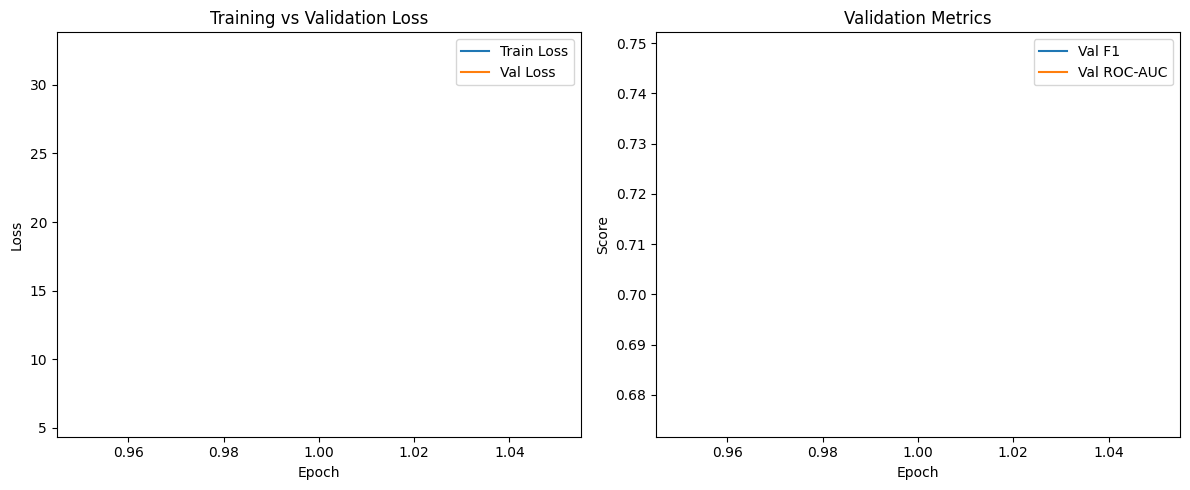

In [29]:
# training curves and validation metrics
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 5))

# LOSS
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# METRICS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_f1_scores, label="Val F1")
plt.plot(epochs_range, val_roc_scores, label="Val ROC-AUC")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Metrics")
plt.legend()

plt.tight_layout()
plt.show()

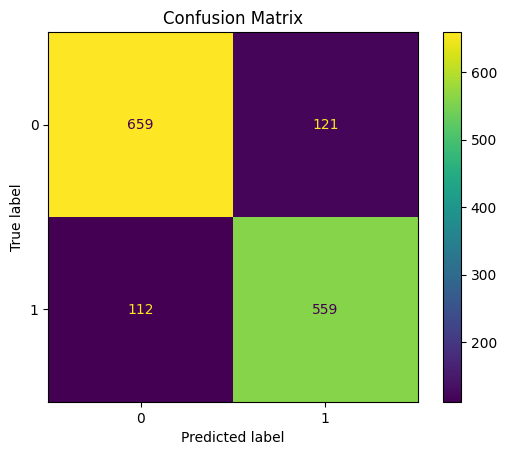

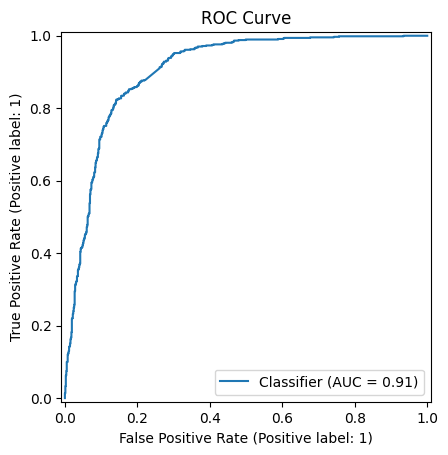

In [30]:
# confunsion matrix
cm = confusion_matrix(labels, binary)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix")
plt.show()

RocCurveDisplay.from_predictions(labels, probs)
plt.title("ROC Curve")
plt.show()

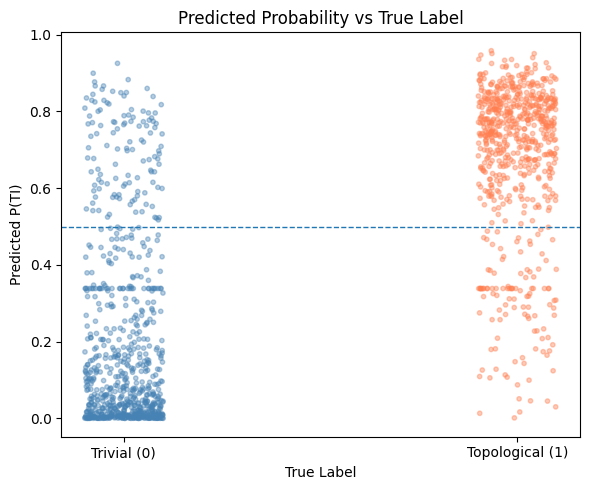

In [31]:
# scatter plot
plt.figure(figsize=(6, 5))

jitter = np.random.uniform(-0.1, 0.1, size=len(labels))

colors = ['steelblue' if l == 0 else 'coral' for l in labels]

plt.scatter(labels + jitter, probs, c=colors, alpha=0.4, s=10)

plt.axhline(0.5, linestyle='--', linewidth=1)

plt.xticks([0, 1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel('True Label')
plt.ylabel('Predicted P(TI)')
plt.title('Predicted Probability vs True Label')

plt.tight_layout()
plt.show()

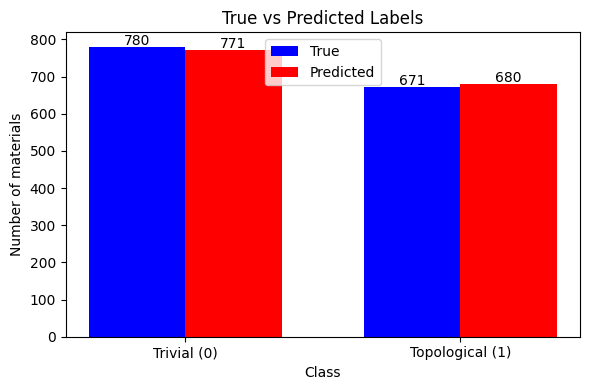

In [32]:
categories = ['Trivial (0)', 'Topological (1)']

true_counts = [(labels == 0).sum(), (labels == 1).sum()]
pred_counts = [(binary == 0).sum(), (binary == 1).sum()]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(6, 4))

bars1 = plt.bar(x - width/2, true_counts, width, label='True', color='blue')
bars2 = plt.bar(x + width/2, pred_counts, width, label='Predicted', color='red')

for bar in list(bars1) + list(bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center')

plt.xticks(x, categories)
plt.xlabel('Class')
plt.ylabel('Number of materials')
plt.title('True vs Predicted Labels')
plt.legend()

plt.tight_layout()
plt.show()

# GAT Model

In [33]:
class CharlesGAT(nn.Module):
    def __init__(self, node_dim, edge_dim, global_dim, hidden_dim=64, heads=4, dropout=0.2):
        super().__init__()

        # Node embedding
        self.node_emb = nn.Linear(node_dim, hidden_dim)

        # GAT layers
        self.gat1 = GATConv(
            hidden_dim,
            hidden_dim,
            heads=heads,
            edge_dim=edge_dim,
            dropout=dropout,
            concat=True
        )

        self.gat2 = GATConv(
            hidden_dim * heads,
            hidden_dim,
            heads=1,
            edge_dim=edge_dim,
            concat=False
        )

        # Global features
        self.global_emb = nn.Linear(global_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout)

        # Output
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, data, return_attention=False):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        u = data.u

        x = F.relu(self.node_emb(x))

        if return_attention:
            x, (edge_idx, attn) = self.gat1(
                x, edge_index, edge_attr,
                return_attention_weights=True
            )
        else:
            x = self.gat1(x, edge_index, edge_attr)

        x = F.elu(x)
        x = self.dropout(x)

        x = F.elu(self.gat2(x, edge_index, edge_attr))

        x = global_mean_pool(x, batch)

        u = F.relu(self.global_emb(u))

        out = self.fc(torch.cat([x, u], dim=1))

        if return_attention:
            return out, edge_idx, attn

        return out

In [34]:
gat_model = CharlesGAT(
    node_dim=5,
    edge_dim=31,
    global_dim=14
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    gat_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

In [35]:
train_losses_gat = []
val_losses_gat = []
val_f1_gat = []
val_roc_gat = []

def train_epoch_gat(loader):
    gat_model.train()
    total_loss = 0

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = gat_model(data)
        loss = criterion(out, data.y.view(-1, 1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch_gat(loader):
    gat_model.eval()
    total_loss = 0
    preds, labels = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = gat_model(data)
            loss = criterion(out, data.y.view(-1, 1))

            total_loss += loss.item()

            probs = torch.sigmoid(out)
            preds.append(probs.cpu())
            labels.append(data.y.cpu())

    preds = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels).numpy().flatten()

    binary = (preds > 0.5).astype(int)

    f1 = f1_score(labels, binary)
    roc = roc_auc_score(labels, preds)

    return total_loss / len(loader), f1, roc
    best_val_loss = float('inf')
patience = 15
counter = 0

EPOCHS = 100

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch_gat(train_loader)
    val_loss, val_f1, val_roc = eval_epoch_gat(val_loader)

    scheduler.step(val_loss)

    train_losses_gat.append(train_loss)
    val_losses_gat.append(val_loss)
    val_f1_gat.append(val_f1)
    val_roc_gat.append(val_roc)

    print(f"[GAT] Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | F1: {val_f1:.4f} | ROC: {val_roc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(gat_model.state_dict(), "best_gat_model.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

[GAT] Epoch 001 | Train: 0.4821 | Val: 0.4329 | F1: 0.7921 | ROC: 0.8792
[GAT] Epoch 002 | Train: 0.4210 | Val: 0.4229 | F1: 0.8021 | ROC: 0.8893
[GAT] Epoch 003 | Train: 0.4038 | Val: 0.4076 | F1: 0.8194 | ROC: 0.8914
[GAT] Epoch 004 | Train: 0.3847 | Val: 0.3973 | F1: 0.8355 | ROC: 0.9027
[GAT] Epoch 005 | Train: 0.3750 | Val: 0.3832 | F1: 0.8344 | ROC: 0.9029
[GAT] Epoch 006 | Train: 0.3624 | Val: 0.3738 | F1: 0.8403 | ROC: 0.9098
[GAT] Epoch 007 | Train: 0.3508 | Val: 0.3793 | F1: 0.8439 | ROC: 0.9151
[GAT] Epoch 008 | Train: 0.3423 | Val: 0.3615 | F1: 0.8380 | ROC: 0.9138
[GAT] Epoch 009 | Train: 0.3372 | Val: 0.3675 | F1: 0.8492 | ROC: 0.9138
[GAT] Epoch 010 | Train: 0.3278 | Val: 0.3650 | F1: 0.8471 | ROC: 0.9172
[GAT] Epoch 011 | Train: 0.3245 | Val: 0.3560 | F1: 0.8421 | ROC: 0.9196
[GAT] Epoch 012 | Train: 0.3203 | Val: 0.3523 | F1: 0.8536 | ROC: 0.9203
[GAT] Epoch 013 | Train: 0.3151 | Val: 0.3454 | F1: 0.8553 | ROC: 0.9208
[GAT] Epoch 014 | Train: 0.3090 | Val: 0.3465 | F1:

In [36]:
gat_model.load_state_dict(torch.load("best_gat_model.pt"))

def evaluate_gat(loader):
    gat_model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = gat_model(data)
            probs = torch.sigmoid(out)

            preds.append(probs.cpu())
            labels_list.append(data.y.cpu())

    probs = torch.cat(preds).numpy().flatten()
    labels = torch.cat(labels_list).numpy().flatten()

    binary = (probs > 0.5).astype(int)

    print("\nGAT Test Performance:")
    print(f"Accuracy : {accuracy_score(labels, binary):.4f}")
    print(f"F1-score : {f1_score(labels, binary):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(labels, probs):.4f}")
    print(classification_report(labels, binary))

    return labels, probs, binary


labels_gat, probs_gat, binary_gat = evaluate_gat(test_loader)


GAT Test Performance:
Accuracy : 0.8787
F1-score : 0.8728
ROC-AUC  : 0.9435
              precision    recall  f1-score   support

         0.0       0.91      0.86      0.88       780
         1.0       0.85      0.90      0.87       671

    accuracy                           0.88      1451
   macro avg       0.88      0.88      0.88      1451
weighted avg       0.88      0.88      0.88      1451



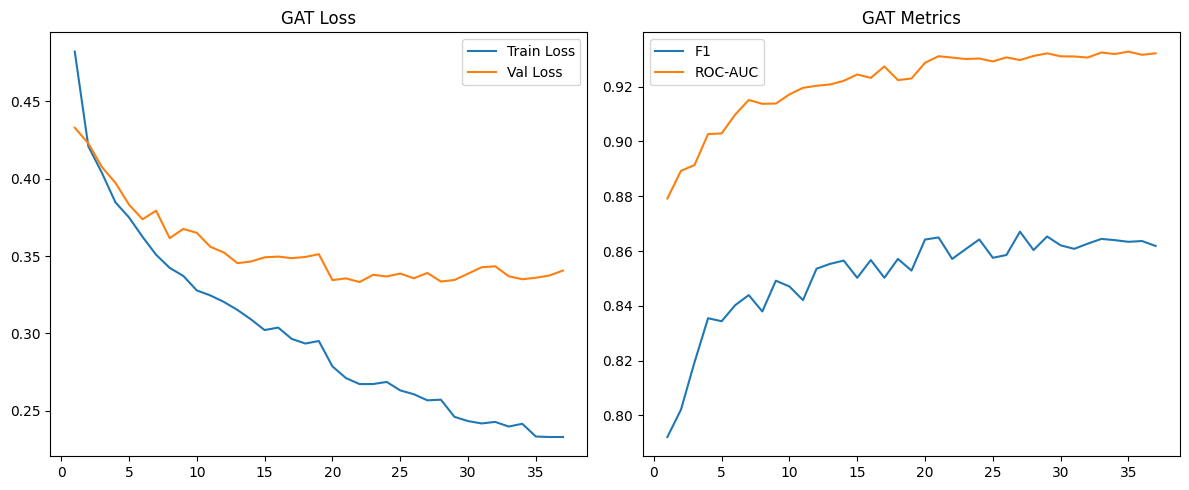

In [37]:
epochs_range = range(1, len(train_losses_gat) + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses_gat, label="Train Loss")
plt.plot(epochs_range, val_losses_gat, label="Val Loss")
plt.legend()
plt.title("GAT Loss")

# Metrics
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_f1_gat, label="F1")
plt.plot(epochs_range, val_roc_gat, label="ROC-AUC")
plt.legend()
plt.title("GAT Metrics")

plt.tight_layout()
plt.show()

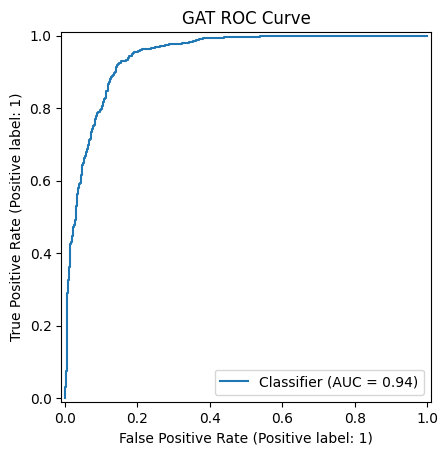

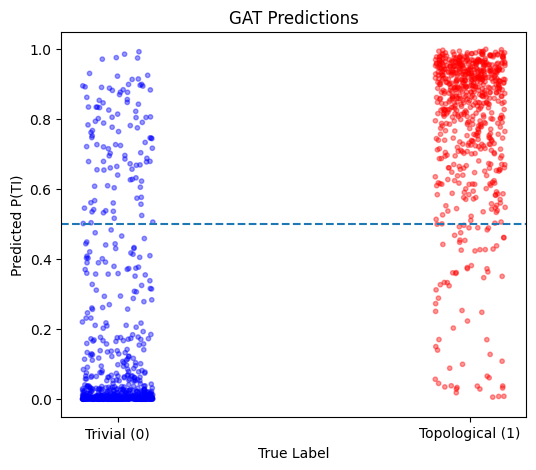

In [38]:
# ROC
RocCurveDisplay.from_predictions(labels_gat, probs_gat)
plt.title("GAT ROC Curve")
plt.show()

# Scatter
plt.figure(figsize=(6,5))

jitter = np.random.uniform(-0.1, 0.1, size=len(labels_gat))
colors = ['blue' if l == 0 else 'red' for l in labels_gat]

plt.scatter(labels_gat + jitter, probs_gat, c=colors, alpha=0.4, s=10)

plt.axhline(0.5, linestyle='--')

plt.xticks([0,1], ['Trivial (0)', 'Topological (1)'])
plt.xlabel("True Label")
plt.ylabel("Predicted P(TI)")
plt.title("GAT Predictions")

plt.show()

In [49]:
gat_model.eval()

# Get one graph (
data_sample = test_dataset[0].to(device)

with torch.no_grad():
    out, edge_index, attn = gat_model(data_sample, return_attention=True)

# Handle multi-head attention
attn = attn.mean(dim=1).squeeze().cpu().numpy()
edge_index = edge_index.cpu().numpy()

In [50]:
node_features_scaled = data_sample.x.cpu().numpy()
node_features_raw = node_scaler.inverse_transform(node_features_scaled)

atomic_numbers = node_features_raw[:, 0]

In [51]:
num_nodes = data_sample.x.shape[0]

node_importance = np.zeros(num_nodes)
node_degree = np.zeros(num_nodes)

for i, (src, dst) in enumerate(edge_index.T):
    node_importance[src] += attn[i]
    node_importance[dst] += attn[i]

    node_degree[src] += 1
    node_degree[dst] += 1

# Normalize by connectivity
node_importance = node_importance / (node_degree + 1e-8)

# Scale to [0,1]
node_importance = (node_importance - node_importance.min()) / (
    node_importance.max() - node_importance.min() + 1e-8
)

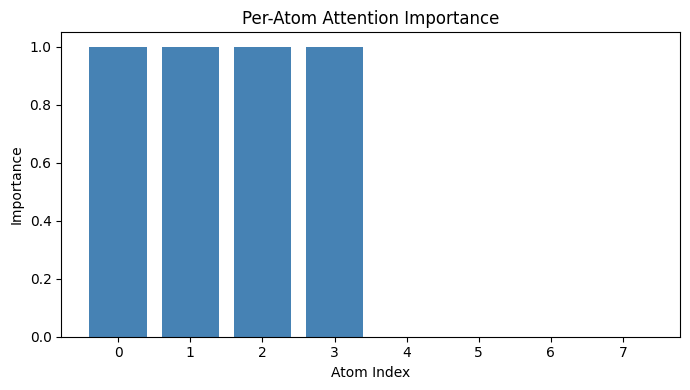

In [52]:
plt.figure(figsize=(7,4))

plt.bar(range(num_nodes), node_importance, color='steelblue')

plt.xlabel("Atom Index")
plt.ylabel("Importance")
plt.title("Per-Atom Attention Importance")

plt.tight_layout()
plt.show()

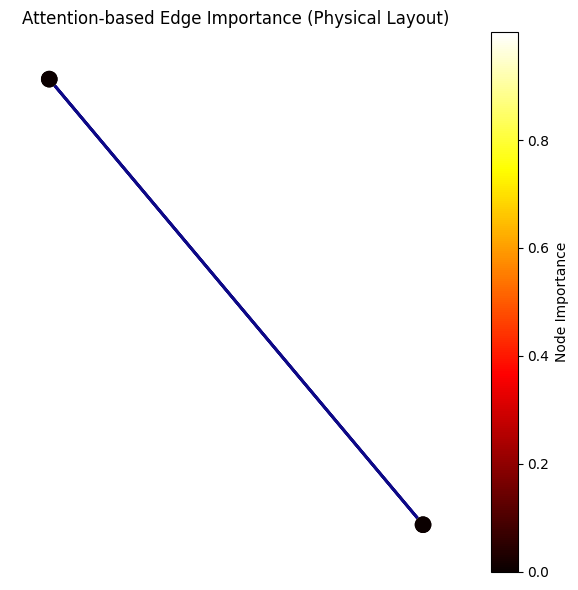

In [56]:
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, ax = plt.subplots(figsize=(6,6))

nx.draw(
    G,
    pos,
    ax=ax,
    node_size=120,
    node_color=node_importance,
    cmap=plt.cm.hot,
    edge_color=weights,
    edge_cmap=plt.cm.plasma,
    width=2
)

# Create proper colorbar
sm = mpl.cm.ScalarMappable(
    cmap=plt.cm.hot,
    norm=plt.Normalize(vmin=node_importance.min(), vmax=node_importance.max())
)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="Node Importance")

ax.set_title("Attention-based Edge Importance (Physical Layout)")

plt.tight_layout()
plt.show()

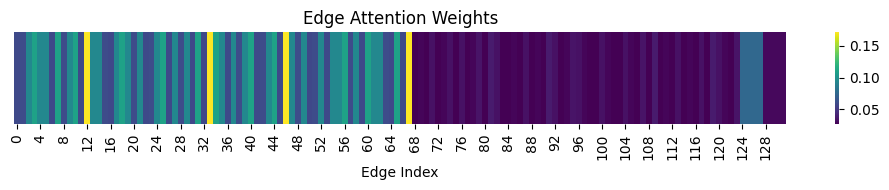

In [54]:
plt.figure(figsize=(10,2))

sns.heatmap(
    attn.reshape(1, -1),
    cmap="viridis",
    cbar=True
)

plt.title("Edge Attention Weights")
plt.xlabel("Edge Index")
plt.yticks([])

plt.tight_layout()
plt.show()

In [55]:
print("\nHigh-importance bonds:\n")

threshold = np.percentile(attn, 90)

for i, (src, dst) in enumerate(edge_index.T):
    if attn[i] > threshold:
        print(
            f"Edge {i}: Atom {src} (Z={atomic_numbers[src]:.0f}) "
            f"↔ Atom {dst} (Z={atomic_numbers[dst]:.0f}) "
            f"| Weight={attn[i]:.3f}"
        )


High-importance bonds:

Edge 3: Atom 0 (Z=31) ↔ Atom 5 (Z=52) | Weight=0.110
Edge 7: Atom 0 (Z=31) ↔ Atom 5 (Z=52) | Weight=0.110
Edge 10: Atom 0 (Z=31) ↔ Atom 5 (Z=52) | Weight=0.110
Edge 12: Atom 0 (Z=31) ↔ Atom 4 (Z=52) | Weight=0.171
Edge 18: Atom 1 (Z=31) ↔ Atom 4 (Z=52) | Weight=0.110
Edge 25: Atom 1 (Z=31) ↔ Atom 4 (Z=52) | Weight=0.110
Edge 31: Atom 1 (Z=31) ↔ Atom 4 (Z=52) | Weight=0.110
Edge 33: Atom 1 (Z=31) ↔ Atom 5 (Z=52) | Weight=0.171
Edge 34: Atom 2 (Z=31) ↔ Atom 7 (Z=52) | Weight=0.110
Edge 40: Atom 2 (Z=31) ↔ Atom 7 (Z=52) | Weight=0.110
Edge 44: Atom 2 (Z=31) ↔ Atom 7 (Z=52) | Weight=0.110
Edge 46: Atom 2 (Z=31) ↔ Atom 6 (Z=52) | Weight=0.171
Edge 67: Atom 3 (Z=31) ↔ Atom 7 (Z=52) | Weight=0.171


In [47]:

X_train = global_samples
y_train = train_df['label'].values

# Apply same scaling
X_train = global_scaler.transform(X_train)

print("Shape:", X_train.shape)

Shape: (6767, 14)


In [48]:

model_sr = PySRRegressor(
    niterations=40,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sqrt", "log", "exp"],
    model_selection="best",
    verbosity=1
)

model_sr.fit(X_train, y_train)

print(model_sr)

Compiling Julia backend...
INFO:pysr.sr:Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 1.940e+03
Progress: 11 / 1240 total iterations (0.887%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.486e-01  0.000e+00  y = 0.4624
5           2.080e-01  4.455e-02  y = (x₉ * -0.20144) + 0.46239
7           2.030e-01  1.225e-02  y = sqrt(0.67184 / (exp(x₁₀) * 1.9301))
8           1.976e-01  2.670e-02  y = sqrt(sqrt(0.40798) / (1.9301 * exp(x₁₀)))
12          1.766e-01  2.812e-02  y = sqrt(((0.69605 * sqrt(0.39344)) + -0.036252) / (1.9301...
                                       * exp(x₁₀)))
17          1.632e-01  1.580e-02  y = sqrt(((sqrt(0.41936 / (exp(x₁₀) * 1.9301)) * 0.69605) ...
                                      + -0.036252) / (exp(x₁₀) * 1.9301))
22          1.632e-01  3.083e-05  y = sqrt(((0.69605 * sqrt((sqrt(-0.036252 + 0.4079

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                         0.46234867   
	1   >>>>  1.521172e-01                              0.34273735 / exp(x10)   
	2         2.505284e-02                  0.09681836 / exp(x10 * 2.7720606)   
	3         3.578957e-02     0.14240561 / (x10 + (0.43075815 - -0.5066936))   
	4         1.317982e-02  sqrt(-0.026745595 / (0.049907148 - (x10 + 0.84...   
	5         3.908606e-03  sqrt(-0.025296526 / (0.05420974 - sqrt(exp(x10...   
	6         1.328827e-03  sqrt(-0.026745595 / (0.052813295 - sqrt(exp(x1...   
	7         6.893965e-04  sqrt(-0.026745595 / (0.052813295 - sqrt(exp(x1...   
	8         2.949054e-02  ((-0.06536187 / (0.0027534496 - sqrt(exp(x10) ...   
	9         1.495410e-03  ((-0.026745595 / (0.052813295 - sqrt(exp(x10) ...   
	10        3.674221e-08  log(exp(((-0.026745595 / (0.052813295 - sqrt(e...   
	11        2.674868e-05  log(exp(((